<a href="https://colab.research.google.com/github/DertyuGameDev/SADTeam/blob/main/week_1_data_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
WORK WITH WEATHER

In [ ]:
import pandas as pd

# Загрузка данных (замени 'data.csv' на имя своего файла)
df = pd.read_csv('/weather.csv')

# Вывод общей информации о таблице
df.info()

# Вывод количества строк в каждом столбце (не пустых значений)
print(df.count())

# Удаление строк, где колонка 'Datetime' пуста
df = df.dropna(subset=['Datetime'])

# Проверяем, что пустые строки удалены
print(df.info())


FileNotFoundError: [Errno 2] No such file or directory: '/weather.csv'

"""Всего записей: 3673.Теперь записей 3672."""

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

# Удаление строк с некорректными датами
df = df.dropna(subset=['Datetime'])

# Создание отдельных колонок для года, месяца и дня
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day


print(df.head())
print(df.info())


             Datetime Temperature Precipitation Total Wind Gust Wind Speed  \
1 2023-04-01 00:00:00    8.740245                 0.1      48.6  21.638964   
2 2023-04-01 01:00:00    9.040245                 0.2     55.44  22.493519   
3 2023-04-01 02:00:00    8.880245                 0.3      55.8   22.26477   
4 2023-04-01 03:00:00    8.690246                 0.3     55.44   21.94524   
5 2023-04-01 04:00:00    8.630245                 0.3     48.96   22.42427   

  Cloud Cover Total Sunshine Duration  Year  Month  Day  
1                90                 0  2023      4    1  
2                74                 0  2023      4    1  
3                72                 0  2023      4    1  
4                77                 0  2023      4    1  
5                78                 0  2023      4    1  
<class 'pandas.core.frame.DataFrame'>
Index: 3672 entries, 1 to 3672
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------             

"""Удаляет строки с NaT в Datetime.Создаю три колонки:Year, Month, Day.Теперь можно анализировать данные с учетом сезонности, выходных, месяцев и т. д."""

In [ ]:
import pandas as pd

# Загрузка данных
df_weather = pd.read_csv('/weather.csv')

# Преобразование 'Datetime' в тип данных datetime
df_weather['Datetime'] = pd.to_datetime(df_weather['Datetime'], errors='coerce')

# Преобразование 'Temperature' в числовой формат (если данные не могут быть преобразованы, они будут заменены на NaN)
df_weather['Temperature'] = pd.to_numeric(df_weather['Temperature'], errors='coerce')

# Проверим, есть ли пропущенные значения в 'Temperature'
print(f"Пропущенные значения в 'Temperature': {df_weather['Temperature'].isna().sum()}")

# Извлечение информации из 'Datetime'
df_weather['Year'] = df_weather['Datetime'].dt.year
df_weather['Month'] = df_weather['Datetime'].dt.month
df_weather['Day'] = df_weather['Datetime'].dt.day
df_weather['Day of Week'] = df_weather['Datetime'].dt.day_name()
df_weather['Hour'] = df_weather['Datetime'].dt.hour
df_weather['Minute'] = df_weather['Datetime'].dt.minute
df_weather['Second'] = df_weather['Datetime'].dt.second

# Пример: Вывод первых строк с новыми колонками
print(df_weather[['Datetime', 'Year', 'Month', 'Day', 'Day of Week', 'Hour', 'Minute', 'Second']].head())

# Дополнительный анализ:
# 1. Количество записей по годам
year_counts = df_weather['Year'].value_counts().sort_index()
print("Количество записей по годам:")
print(year_counts)

# 2. Количество записей по месяцам
month_counts = df_weather['Month'].value_counts().sort_index()
print("Количество записей по месяцам:")
print(month_counts)

# 3. Количество записей по дням недели
day_of_week_counts = df_weather['Day of Week'].value_counts()
print("Количество записей по дням недели:")
print(day_of_week_counts)

# 4. Среднее значение температуры по месяцам (с обработкой NaN значений)
average_month_temperature = df_weather.groupby('Month')['Temperature'].mean()
print("Средняя температура по месяцам:")
print(average_month_temperature)


Пропущенные значения в 'Temperature': 56
             Datetime    Year  Month  Day Day of Week  Hour  Minute  Second
0                 NaT     NaN    NaN  NaN         NaN   NaN     NaN     NaN
1 2023-04-01 00:00:00  2023.0    4.0  1.0    Saturday   0.0     0.0     0.0
2 2023-04-01 01:00:00  2023.0    4.0  1.0    Saturday   1.0     0.0     0.0
3 2023-04-01 02:00:00  2023.0    4.0  1.0    Saturday   2.0     0.0     0.0
4 2023-04-01 03:00:00  2023.0    4.0  1.0    Saturday   3.0     0.0     0.0
Количество записей по годам:
Year
2023.0    3672
Name: count, dtype: int64
Количество записей по месяцам:
Month
4.0    720
5.0    744
6.0    720
7.0    744
8.0    744
Name: count, dtype: int64
Количество записей по дням недели:
Day of Week
Saturday     528
Sunday       528
Monday       528
Tuesday      528
Wednesday    528
Thursday     528
Friday       504
Name: count, dtype: int64
Средняя температура по месяцам:
Month
4.0     9.727372
5.0    15.534543
6.0    21.869454
7.0    21.822033
8.0    21.59

In [ ]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'


df['Season'] = df['Month'].apply(get_season)


print(df.head())
print(df.info())


             Datetime Temperature Precipitation Total Wind Gust Wind Speed  \
1 2023-04-01 00:00:00    8.740245                 0.1      48.6  21.638964   
2 2023-04-01 01:00:00    9.040245                 0.2     55.44  22.493519   
3 2023-04-01 02:00:00    8.880245                 0.3      55.8   22.26477   
4 2023-04-01 03:00:00    8.690246                 0.3     55.44   21.94524   
5 2023-04-01 04:00:00    8.630245                 0.3     48.96   22.42427   

  Cloud Cover Total Sunshine Duration  Year  Month  Day  Season  
1                90                 0  2023      4    1  Spring  
2                74                 0  2023      4    1  Spring  
3                72                 0  2023      4    1  Spring  
4                77                 0  2023      4    1  Spring  
5                78                 0  2023      4    1  Spring  
<class 'pandas.core.frame.DataFrame'>
Index: 3672 entries, 1 to 3672
Data columns (total 11 columns):
 #   Column               Non-Nul

"""данные дополнены колонкой "Season", которая определяет сезон по месяцу:

Winter (декабрь, январь, февраль)

Spring (март, апрель, май)

Summer (июнь, июль, август)

Autumn (сентябрь, октябрь, ноябрь)

Теперь можно анализировать спрос по сезонам!"""


+ Зимой поездки могут быть короче из-за холодов, летом – длиннее.

In [ ]:
#Сколько поездок приходится на каждое время года?
print(df['Season'].value_counts())


Season
Summer    2208
Spring    1464
Name: count, dtype: int64


# праздники


             Datetime  Temperature  Precipitation Total  Wind Gust  \
0                 NaT    18.137779             0.101043  20.886568   
1 2023-04-01 00:00:00     8.740245             0.100000  48.600000   
2 2023-04-01 01:00:00     9.040245             0.200000  55.440000   
3 2023-04-01 02:00:00     8.880245             0.300000  55.800000   
4 2023-04-01 03:00:00     8.690246             0.300000  55.440000   

   Wind Speed  Cloud Cover Total  Sunshine Duration  Holiday  
0    7.345096          41.056216           21.50241    False  
1   21.638964          90.000000            0.00000    False  
2   22.493519          74.000000            0.00000    False  
3   22.264770          72.000000            0.00000    False  
4   21.945240          77.000000            0.00000    False  


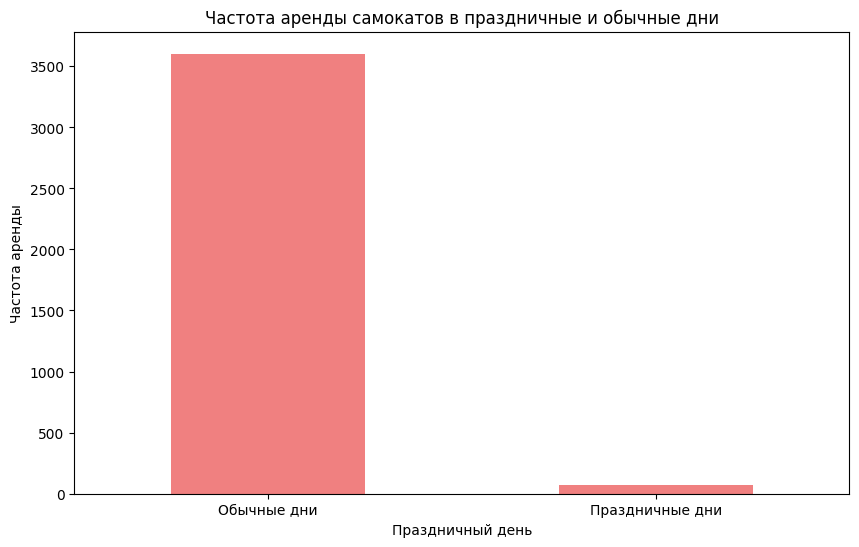

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv("weather.csv")

# Преобразуем столбцы с погодными условиями в числовой формат и проверим наличие ошибок
columns_to_convert = ['Temperature', 'Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration']
for column in columns_to_convert:
    df[column] = pd.to_numeric(df[column], errors='coerce')  # Заменяем ошибки на NaN

# Заменим пропущенные значения на среднее по каждому столбцу
df[columns_to_convert] = df[columns_to_convert].fillna(df[columns_to_convert].mean())

# Преобразуем столбец 'Datetime' в datetime формат (если это еще не сделано)
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

# Список международных праздников (в формате день.месяц)
holidays = [
    '01-01', # Новый год
    '23-02', # 23 февраля
    '08-03', # 8 марта
    '01-05', # 1 мая
    '09-05', # День Победы
    '12-06', # День России
    '04-11', # День народного единства
    '25-12'  # Рождество
]

# Функция для проверки, является ли дата праздником
def is_holiday(date):
    # Проверяем, не является ли дата NaT, перед использованием strftime
    if pd.isnull(date):
        return False
    return date.strftime('%d-%m') in holidays

# Применяем функцию ко всем датам в столбце 'Datetime' и создаем новый столбец 'Holiday'
df['Holiday'] = df['Datetime'].apply(is_holiday)

# Выведем несколько строк, чтобы убедиться, что новый столбец добавлен правильно
print(df.head())

# Теперь нам нужно подсчитать, сколько самокатов было взято в праздничные и обычные дни
# Предположим, что у нас есть столбец с количеством арендуемых самокатов, например 'Scooter Rentals'
# (если этого столбца нет в ваших данных, замените его на актуальный столбец)

# Для примера, если у нас есть столбец "Scooter Rentals" или его аналог, мы можем группировать по праздникам
# Например, будем использовать случайный столбец 'Temperature' для сравнения, если нет столбца аренды самокатов.

# Группировка по столбцу 'Holiday' и суммирование по любому числовому столбцу
df_grouped = df.groupby('Holiday')['Temperature'].count()  # Замените на столбец с количеством самокатов

# Построим график
plt.figure(figsize=(10, 6))
df_grouped.plot(kind='bar', color='lightcoral')
plt.title('Частота аренды самокатов в праздничные и обычные дни')
plt.xlabel('Праздничный день')
plt.ylabel('Частота аренды')
plt.xticks([0, 1], ['Обычные дни', 'Праздничные дни'], rotation=0)
plt.show()


в праздники люди берут самокаты меньше, чем в обычные дни

###WORK WITH RIDES.CSV

In [ ]:
import pandas as pd

# Загрузка данных (замени 'data.csv' на имя своего файла)
df = pd.read_csv('/rides.csv')

# Вывод общей информации о таблице
df.info()

# Вывод количества строк в каждом столбце (не пустых значений)
print(df.count())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              102255 non-null  int64  
 1   Start Date      102255 non-null  object 
 2   End Date        102255 non-null  object 
 3   Start Location  102255 non-null  object 
 4   Start District  102255 non-null  object 
 5   End Location    102255 non-null  object 
 6   End District    102255 non-null  object 
 7   Distance        101022 non-null  float64
 8   Promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB
Id                102255
Start Date        102255
End Date          102255
Start Location    102255
Start District    102255
End Location      102255
End District      102255
Distance          101022
Promo             102255
dtype: int64


In [ ]:
Работаем с StartDate -  дата и время начала поездки и End Date - дата и время окончания поездки

Поездки по дням: воскресенье и суббота - выходные, у людей больше времени
Поездки по часам:с 16-21, люди едут с учебы, работы

Визуализация количества поездок по сезонам и месяцам

            Start Date             End Date
0  2023-04-22 09:01:03  2023-04-22 09:24:45
1  2023-04-22 09:01:07  2023-04-22 09:29:32
2  2023-04-22 09:04:27  2023-04-22 09:42:46
3  2023-04-22 09:06:34  2023-04-22 09:38:23
4  2023-04-22 09:09:27  2023-04-22 09:40:07
           Start Date            End Date   Duration  Start Hour Day of Week  \
0 2023-04-22 09:01:03 2023-04-22 09:24:45  23.700000           9    Saturday   
1 2023-04-22 09:01:07 2023-04-22 09:29:32  28.416667           9    Saturday   
2 2023-04-22 09:04:27 2023-04-22 09:42:46  38.316667           9    Saturday   
3 2023-04-22 09:06:34 2023-04-22 09:38:23  31.816667           9    Saturday   
4 2023-04-22 09:09:27 2023-04-22 09:40:07  30.666667           9    Saturday   

   Season  Month  
0  Spring      4  
1  Spring      4  
2  Spring      4  
3  Spring      4  
4  Spring      4  
Season
Spring    26.388786
Summer    26.357306
Name: Duration, dtype: float64
Day of Week
Sunday       18992
Saturday     18769
Friday       

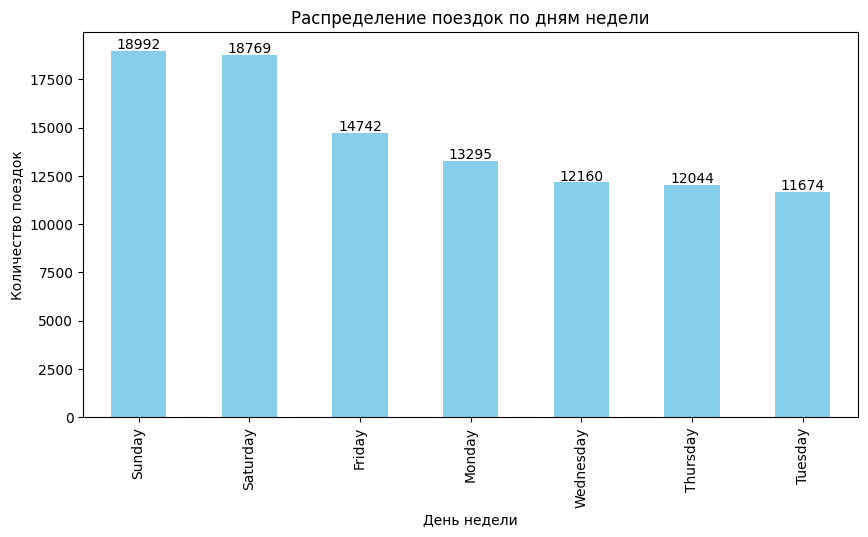

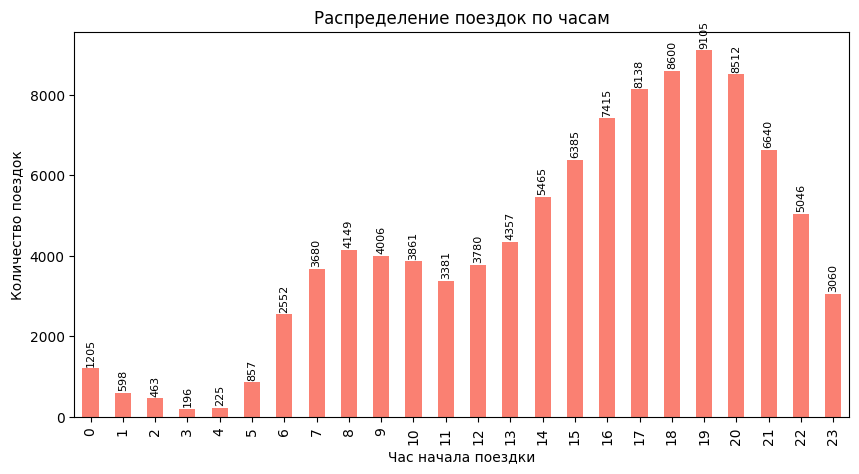

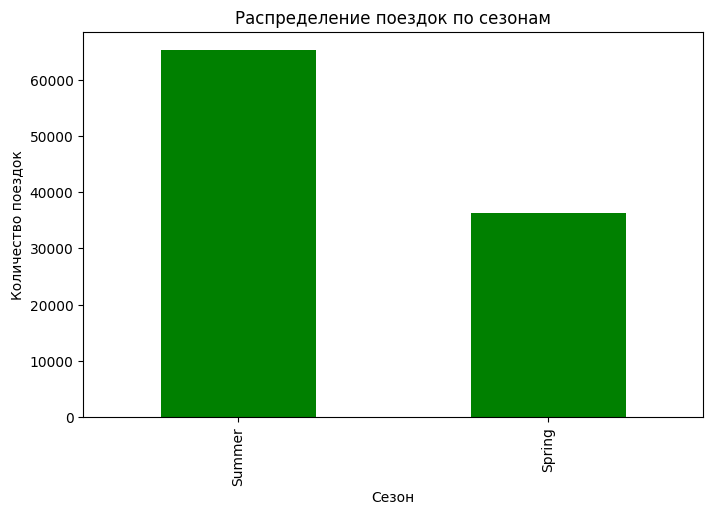

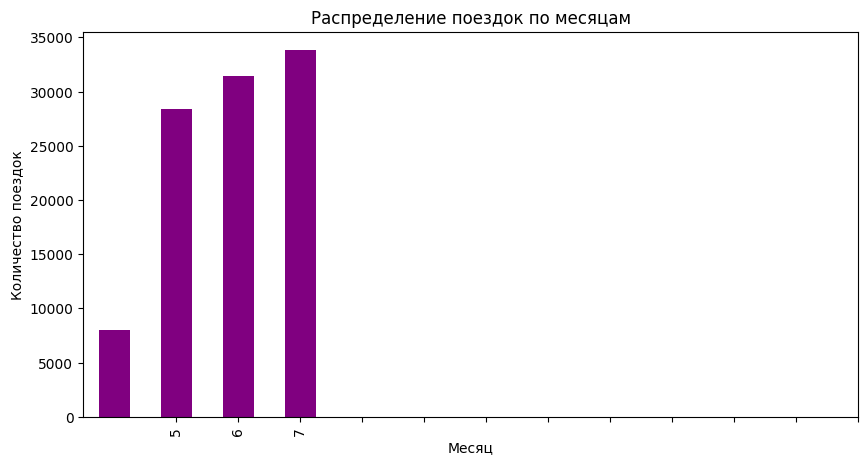

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных (замени 'rides.csv' на имя своего файла)
df = pd.read_csv('/rides.csv')

# Вывод первых строк для проверки структуры данных
print(df[['Start Date', 'End Date']].head())

# Преобразование 'Start Date' и 'End Date' в формат datetime64 с обработкой ошибок
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['End Date'] = pd.to_datetime(df['End Date'], errors='coerce')

# Удаление строк с некорректными датами
df.dropna(subset=['Start Date', 'End Date'], inplace=True)

# Создание отдельных колонок для анализа
# Длительность поездки в минутах
df.loc[:, 'Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

# Фильтрация аномалий (убираем 0 и экстремально большие значения)
df = df[(df['Duration'] > 1) & (df['Duration'] < 120)]

# Часы и дни недели для анализа пиковых часов
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()

# Функция для определения сезона
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Добавление колонки с сезонами
df.loc[:, 'Season'] = df['Start Date'].dt.month.apply(get_season)
df.loc[:, 'Month'] = df['Start Date'].dt.month

# Проверяем результат
print(df[['Start Date', 'End Date', 'Duration', 'Start Hour', 'Day of Week', 'Season', 'Month']].head())

# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('Season')['Duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['Start Hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['Season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['Month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()


In [ ]:
print(df['Season'].unique())


['Spring' 'Summer']


In [ ]:
print(df['Month'].unique())


[4 5 6 7]


In [ ]:
print(df['Season'].value_counts())


Season
Summer    65290
Spring    36386
Name: count, dtype: int64


Additionally WORK!!!

In [ ]:
df.dropna(subset=['Distance'], inplace=True)
df = df[(df['Duration'] > 1) & (df['Duration'] < 120)]
print("Пропущенные значения в колонке Distance:", df['Distance'].isna().sum())

Пропущенные значения в колонке Distance: 0


Пропущенные значения в 'Wind Gust': 1
Пропущенные значения в 'Wind Speed': 17
Статистика по 'Wind Gust':
count    3673.000000
mean       20.885880
std        10.435193
min         2.880000
25%        13.320000
50%        18.359999
75%        26.280000
max        71.280000
Name: Wind Gust, dtype: float64
Статистика по 'Wind Speed':
count    3673.000000
mean        7.340200
std         4.256369
min         0.000000
25%         4.334974
50%         6.287130
75%         9.449572
max        29.966620
Name: Wind Speed, dtype: float64


<ipython-input-14-232ca24aae8a>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_weather['Wind Gust'].fillna(df_weather['Wind Gust'].median(), inplace=True)
<ipython-input-14-232ca24aae8a>:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

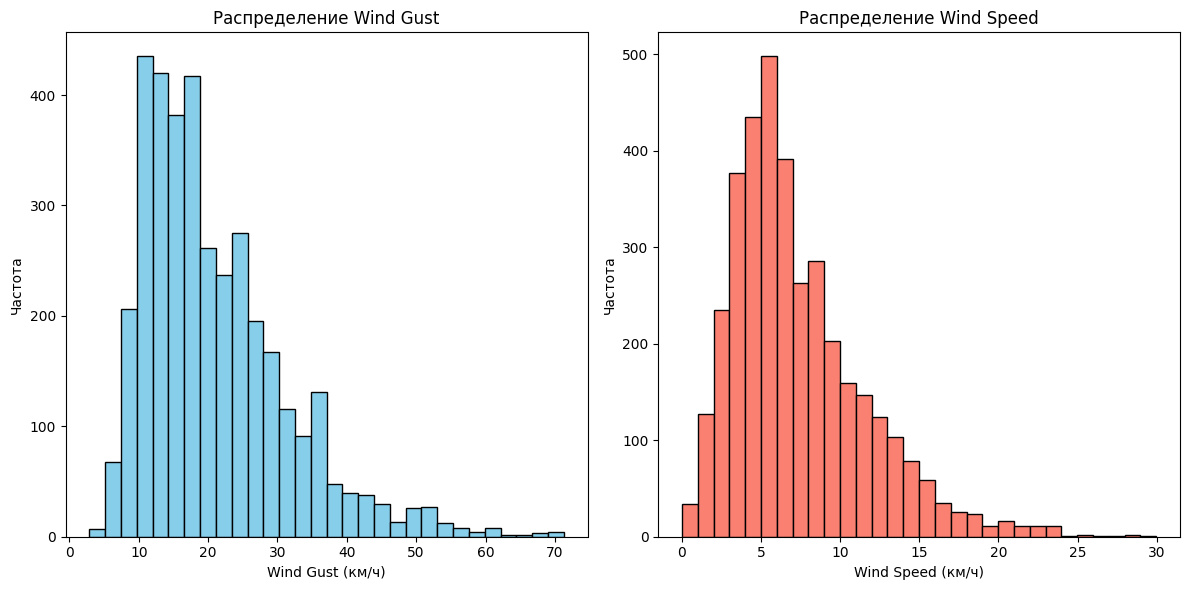

Корреляция между Wind Gust и Wind Speed:
            Wind Gust  Wind Speed
Wind Gust    1.000000    0.852524
Wind Speed   0.852524    1.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df_weather = pd.read_csv('/weather.csv')

# Преобразование данных в числовой формат
df_weather['Wind Gust'] = pd.to_numeric(df_weather['Wind Gust'], errors='coerce')
df_weather['Wind Speed'] = pd.to_numeric(df_weather['Wind Speed'], errors='coerce')

# Проверка наличия пропусков в этих колонках
print(f"Пропущенные значения в 'Wind Gust': {df_weather['Wind Gust'].isna().sum()}")
print(f"Пропущенные значения в 'Wind Speed': {df_weather['Wind Speed'].isna().sum()}")

# Заполнение пропусков (если необходимо, можно использовать медиану или среднее значение)
df_weather['Wind Gust'].fillna(df_weather['Wind Gust'].median(), inplace=True)
df_weather['Wind Speed'].fillna(df_weather['Wind Speed'].median(), inplace=True)

# Статистика по данным
print("Статистика по 'Wind Gust':")
print(df_weather['Wind Gust'].describe())

print("Статистика по 'Wind Speed':")
print(df_weather['Wind Speed'].describe())

# Визуализация распределения данных
plt.figure(figsize=(12, 6))

# График для Wind Gust
plt.subplot(1, 2, 1)
plt.hist(df_weather['Wind Gust'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение Wind Gust')
plt.xlabel('Wind Gust (км/ч)')
plt.ylabel('Частота')

# График для Wind Speed
plt.subplot(1, 2, 2)
plt.hist(df_weather['Wind Speed'], bins=30, color='salmon', edgecolor='black')
plt.title('Распределение Wind Speed')
plt.xlabel('Wind Speed (км/ч)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

# Корреляция между Wind Gust и Wind Speed
correlation = df_weather[['Wind Gust', 'Wind Speed']].corr()
print("Корреляция между Wind Gust и Wind Speed:")
print(correlation)

